In [1]:
import pandas as pd
from scipy.stats import variation
import matplotlib.pyplot as plt

In [2]:
tvs_per_wb_df = pd.read_csv(r"X:\pervasive_group\Shared\MobiliseD TVS\Sharepoint dataset\TVS-Final-DMO-Dataset\tvs-wb-dmo-17-05-2023.csv")

metadata = pd.read_csv(r"X:\pervasive_group\Shared\MobiliseD TVS\Sharepoint dataset\TVS-Final-Clinical-Dataset\study-instances-Cohort Site-2023-03-01h15m31s39.csv")

# get HA ids from metadata file
HA_participant_ids = metadata[metadata["Cohort HA"] == "T"]["Local Participant"]

# trim wb file to only HA participants
tvs_per_wb_df = tvs_per_wb_df[tvs_per_wb_df["participantid"].isin(HA_participant_ids)]

In [3]:
tvs_daily_dmos = pd.DataFrame()

for participant in tvs_per_wb_df["participantid"].unique():
    per_wb_participant_df = tvs_per_wb_df[tvs_per_wb_df["participantid"] == participant]

    #calculate aggregate DMOs per day
    for day in per_wb_participant_df["wbday"].unique():
        per_day_wb_participant_df = per_wb_participant_df[per_wb_participant_df["wbday"] == day]

        # get subset wb durations
        wb_10 = per_day_wb_participant_df[per_day_wb_participant_df["duration"] > 10]
        wb_10_30 = per_day_wb_participant_df[(per_day_wb_participant_df["duration"] > 10) & (per_day_wb_participant_df["duration"] < 30)]
        wb_30 = per_day_wb_participant_df[per_day_wb_participant_df["duration"] > 30]
        wb_60 = per_day_wb_participant_df[per_day_wb_participant_df["duration"] > 60]

        daily_level_dmos_df = pd.DataFrame(index=[0])
        daily_level_dmos_df["participant_id"] = participant
        daily_level_dmos_df["day"] = day

        # amount
        daily_level_dmos_df["walkdur_all_sum_d"] = per_day_wb_participant_df["duration"].sum()
        daily_level_dmos_df["steps_all_sum_d"] = per_day_wb_participant_df["numberstrides"].sum() # should be steps but number of steps aren't included in the per-wb DMOs?

        # pattern
        daily_level_dmos_df["wb_all_sum_d"] = len(per_day_wb_participant_df)
        daily_level_dmos_df["wb_10_sum_d"] = len(wb_10)
        daily_level_dmos_df["wb_30_sum_d"] = len(wb_30)
        daily_level_dmos_df["wb_60_sum_d"] = len(wb_60)
        daily_level_dmos_df["wbdur_all_avg_d"] = per_day_wb_participant_df["duration"].median()
        daily_level_dmos_df["wbdur_all_p90_d"] = per_day_wb_participant_df["duration"].quantile(0.9)
        daily_level_dmos_df["wbdur_all_var_d"] = variation(per_day_wb_participant_df["duration"])

        # pace
        daily_level_dmos_df["ws_1030_avg_d"] = wb_10_30["averagestridespeed"].mean()
        daily_level_dmos_df["ws_30_avg_d"] = wb_30["averagestridespeed"].mean()
        daily_level_dmos_df["ws_10_p90_d"] = wb_10["averagestridespeed"].quantile(0.9)
        daily_level_dmos_df["ws_30_p90_d"] = wb_30["averagestridespeed"].quantile(0.9)
        daily_level_dmos_df["strlen_1030_avg_d"] = wb_10_30["averagestridelength"].mean()
        daily_level_dmos_df["strlen_30_avg_d"] = wb_30["averagestridelength"].mean()

        # rhythm
        daily_level_dmos_df["cadence_all_avg_d"] = per_day_wb_participant_df["averagecadence"].mean()
        daily_level_dmos_df["cadence_30_avg_d"] = wb_30["averagecadence"].mean()
        daily_level_dmos_df["cadence_30_p90_d"] = wb_30["averagecadence"].quantile(0.9)
        daily_level_dmos_df["strdur_all_avg_d"] = per_day_wb_participant_df["averagestrideduration"].mean()
        daily_level_dmos_df["strdur_30_avg_d"] = wb_30["averagestrideduration"].mean()

        # bout to bout variability
        daily_level_dmos_df["ws_30_var_d"] = variation(wb_30["averagestridespeed"])
        daily_level_dmos_df["strlen_30_var_d"] = variation(wb_30["averagestridelength"])
        daily_level_dmos_df["cadence_all_var_d"] = variation(per_day_wb_participant_df["averagecadence"])
        daily_level_dmos_df["strdur_all_var_d"] = variation(per_day_wb_participant_df["averagestrideduration"])

        tvs_daily_dmos = pd.concat([tvs_daily_dmos, daily_level_dmos_df], ignore_index=True)

tvs_weekly_dmos = pd.DataFrame()
for participant in tvs_daily_dmos["participant_id"].unique():
    all_days_dmos_df = tvs_daily_dmos[tvs_daily_dmos["participant_id"] == participant].filter(regex="_d$").mean().to_frame().T
    all_days_dmos_df["participant_id"] = participant
    tvs_weekly_dmos = pd.concat([tvs_weekly_dmos, all_days_dmos_df], ignore_index=True)

#print(tvs_daily_dmos)
#print(tvs_weekly_dmos)

C:\Users\ac4jmi\AppData\Local\Temp\ipykernel_91088\66298831.py:49: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  daily_level_dmos_df["ws_30_var_d"] = variation(wb_30["averagestridespeed"])
C:\Users\ac4jmi\AppData\Local\Temp\ipykernel_91088\66298831.py:50: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  daily_level_dmos_df["strlen_30_var_d"] = variation(wb_30["averagestridelength"])
C:\Users\ac4jmi\AppData\Local\Temp\ipykernel_91088\66298831.py:49: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  daily_level_dmos_df["ws_30_var_d"] = variation(wb_30["averagestridespeed"])
C:\Users\ac4jmi\AppData\Local\Temp\ipykernel_91088\66298831.py:50: SmallSampleWarning: One or more sample arguments is too small

    walkdur_all_sum_d  steps_all_sum_d  wb_all_sum_d  wb_10_sum_d  \
0         5285.835000      6580.800000    360.800000   174.600000   
1         6458.471429      9097.142857    517.142857   189.428571   
2         1937.871429      2513.857143     99.428571    47.571429   
3         3516.671429      4552.285714    308.857143   121.428571   
4         5319.900000      7133.142857    331.571429   153.428571   
5         3262.467857      4692.285714    239.571429    73.285714   
6        10291.653571     16435.000000    249.000000   134.142857   
7         7024.542857      9522.285714    527.571429   199.857143   
8         5471.150000      8645.714286    301.142857   123.571429   
9         5826.360714      8172.714286    379.000000   169.571429   
10        5168.132143      7087.142857    353.714286   179.000000   
11        8778.185714     14732.714286    284.285714   130.714286   
12        8106.392857     11700.000000    320.857143   136.571429   
13        9034.760714     16543.42

In [4]:
dmo4lnc_per_wb_df = pd.read_csv("Free-Living Parameters/per_wb_parameters.csv")
dmo4lnc_daily_dmos = pd.read_csv("Free-Living Parameters/all_day_parameters.csv")
dmo4lnc_weekly_dmos = pd.read_csv("Free-Living Parameters/weekly_parameters.csv")

dmo4lnc_per_wb_cp_df = dmo4lnc_per_wb_df[dmo4lnc_per_wb_df["cohort"] == "CP"]
dmo4lnc_daily_cp_dmos = dmo4lnc_daily_dmos[dmo4lnc_daily_dmos["cohort"] == "CP"]
dmo4lnc_weekly_cp_dmos = dmo4lnc_weekly_dmos[dmo4lnc_weekly_dmos["cohort"] == "CP"]


mean DMO4LNC CP Cadence: 87.96178158768377
mean TVS HA Cadence: 95.29078346225307
87.37362622325236
95.694301135524


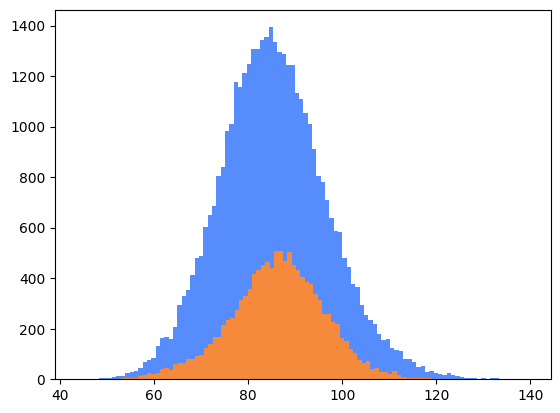

In [13]:
print(f"mean DMO4LNC CP Cadence: {dmo4lnc_weekly_dmos["wb_30__cadence_spm__avg_w"].mean()}")
print(f"mean TVS HA Cadence: {tvs_weekly_dmos["cadence_30_avg_d"].mean()}")

print(dmo4lnc_weekly_dmos["wb_30__cadence_spm__avg_w"].median())
print(tvs_weekly_dmos["cadence_30_avg_d"].median())

plt.figure()
plt.hist(tvs_per_wb_df["averagecadence"], bins=100)
plt.hist(dmo4lnc_per_wb_cp_df["cadence_spm"], bins=100)
plt.show()